# Convolutional Autoencoder &mdash; minimal latent space for an RL state encoder

**Goal:** compress 28&times;28 grayscale images into the *smallest possible* latent vector that still
reconstructs the images well, so the latent can be fed to an RL algorithm as a compact state.

**How the search works:** learning rate and batch size are fixed at sensible defaults (you said you
don't care about them). The only thing we search over is `latent_dim`. We train one model per
candidate dimension, then pick the **smallest** dimension whose reconstruction loss is still within a
chosen tolerance of the best loss any dimension achieved. That tolerance (`TOL`) is the single knob that
controls the size-vs-accuracy tradeoff.

Pipeline: `1x28x28 -> conv -> 32x14x14 -> conv -> 64x7x7 -> flatten -> linear -> z(dim D)`
and the decoder mirrors it back up to `1x28x28`.

## 1. Imports and configuration

In [6]:
import os, glob, time, math, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt

# ----------------------------- CONFIG -----------------------------
DATA_PATH = "Formations" # dir of images, OR a .npy / .pt file

LATENT_DIMS = [64] # candidate latent sizes (smallest first when selecting)

# A dim is "acceptable" if its val loss is within TOL of the best val loss across all dims.
# Smaller TOL: Insist on near-best reconstruction -> larger latent.
# Larger TOL: Tolerate more reconstruction error -> smaller latent.
TOL = 0.02

# Fixed defaults:
LR = 1e-3
BATCH_SIZE = 256
MAX_EPOCHS = 60
PATIENCE = 6 # early-stopping threshold on val loss
VAL_FRAC = 0.1
BASE_CH = 32 # encoder first-layer channels (second layer = 2x)
SEED = 0
OUT_DIR = "ae_outputs"
# ------------------------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


## 2. Load the data

The loader auto-detects the format from `DATA_PATH` and returns a float tensor of shape
`(N, 1, 28, 28)` scaled to `[0, 1]`:

- **Directory** of `.png`/`.jpg` images
- **`.npy`** array, shape `(N,28,28)`, `(N,1,28,28)`, or `(N,784)`
- **`.pt`** tensor, same shapes as above
- **`.csv`** with 784 pixel columns per row (an optional label column is dropped automatically)

If `DATA_PATH` doesn't exist, it falls back to downloading MNIST via torchvision so you can run the
whole notebook end-to-end as a sanity check. Replace `DATA_PATH` with your real data and re-run.

In [7]:
def _to_tensor(arr):
    t = torch.as_tensor(np.asarray(arr), dtype=torch.float32)
    if t.ndim == 2 and t.shape[1] in (784, 28 * 28): # (N, 784)
        t = t.view(-1, 1, 28, 28)
    elif t.ndim == 3: # (N, 28, 28)
        t = t.unsqueeze(1)
    elif t.ndim == 4: # (N, 1, 28, 28) or (N, 28, 28, 1)
        if t.shape[1] != 1 and t.shape[-1] == 1:
            t = t.permute(0, 3, 1, 2)
    else:
        raise ValueError(f"Unexpected data shape {tuple(t.shape)}")
    if t.max() > 1.5: # looks like 0-255
        t = t / 255.0
    return t.clamp(0, 1)

def load_images(path):
    if os.path.isdir(path):
        from PIL import Image
        files = sorted(glob.glob(os.path.join(path, "**", "*.*"), recursive=True))
        files = [f for f in files if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))]
        if not files:
            raise FileNotFoundError(f"No image files found under {path}")
        imgs = [np.array(Image.open(f).convert("L").resize((28, 28))) for f in files]
        return _to_tensor(np.stack(imgs))
    if path.endswith(".npy"):
        return _to_tensor(np.load(path))
    if path.endswith(".pt"):
        return _to_tensor(torch.load(path))
    raise FileNotFoundError(path)

if os.path.exists(DATA_PATH):
    X = load_images(DATA_PATH)
else:
    print(f"'{DATA_PATH}' not found, Exiting.")

print("Dataset tensor:", tuple(X.shape), "min", float(X.min()), "max", float(X.max()))

# Train / validation split (shared across all latent dims for a fair comparison)
full = TensorDataset(X)
n_val = int(len(full) * VAL_FRAC)
n_tr  = len(full) - n_val
g = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full, [n_tr, n_val], generator=g)
print(f"train={len(train_ds)}  val={len(val_ds)}")

Dataset tensor: (172500, 1, 28, 28) min 0.0 max 1.0
train=155250  val=17250


## 3. Model

In [8]:
class ConvAutoencoder(nn.Module):
    """Symmetric conv autoencoder for 1x28x28 inputs. latent_dim is the only structural variable."""
    def __init__(self, latent_dim, base_ch=BASE_CH):
        super().__init__()
        c1, c2 = base_ch, base_ch * 2
        self._c2 = c2
        self.flat_dim = c2 * 7 * 7

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, c1, 3, stride=2, padding=1), nn.ReLU(inplace=True), # 28 -> 14
            nn.Conv2d(c1, c2, 3, stride=2, padding=1), nn.ReLU(inplace=True), # 14 -> 7
        )
        self.enc_fc = nn.Linear(self.flat_dim, latent_dim)
        self.dec_fc = nn.Linear(latent_dim, self.flat_dim)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(c2, c1, 3, stride=2, padding=1, output_padding=1), nn.ReLU(inplace=True), # 7 -> 14
            nn.ConvTranspose2d(c1, 1, 3, stride=2, padding=1, output_padding=1), # 14 -> 28
        )

    def encode(self, x):
        return self.enc_fc(self.encoder_conv(x).flatten(1))

    def decode(self, z):
        h = self.dec_fc(z).view(-1, self._c2, 7, 7)
        return torch.sigmoid(self.decoder_conv(h))

    def forward(self, x):
        return self.decode(self.encode(x))

## 4. Train / evaluate one configuration

BCE reconstruction loss (the output is a sigmoid, inputs are in `[0,1]`). We also report mean squared
error as a more intuitive per-pixel number. Early stopping restores the best-val-loss weights.

In [9]:
def evaluate(model, loader):
    model.eval()
    bce_fn = nn.BCELoss(reduction="sum")
    tot_bce = tot_mse = n = 0
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            tot_bce += bce_fn(out, xb).item()
            tot_mse += ((out - xb) ** 2).sum().item()
            n += xb.numel()
    return tot_bce / n, tot_mse / n # per-pixel BCE, per-pixel MSE

def train_one(latent_dim, verbose=True):
    torch.manual_seed(SEED)
    tr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    va = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    model = ConvAutoencoder(latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    bce_fn = nn.BCELoss()

    best_val = math.inf; best_state = None; bad = 0
    for ep in range(MAX_EPOCHS):
        model.train()
        for (xb,) in tr:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            loss = bce_fn(model(xb), xb)
            loss.backward()
            opt.step()
        val_bce, val_mse = evaluate(model, va)
        if val_bce < best_val - 1e-5:
            best_val = val_bce
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best_state)
    final_bce, final_mse = evaluate(model, va)
    n_params = sum(p.numel() for p in model.parameters())
    if verbose:
        print(f"  latent_dim={latent_dim:>3} | epochs={ep+1:>2} | "
              f"val BCE={final_bce:.5f} | val MSE={final_mse:.5f} | params={n_params:,}")
    return {"latent_dim": latent_dim, "val_bce": final_bce, "val_mse": final_mse,
            "epochs": ep + 1, "params": n_params, "model": model}

## 5. Sweep `latent_dim`

Train one model per candidate dimension. This is the search.

In [10]:
results = []
t0 = time.time()
print("Sweeping latent_dim:")
for D in LATENT_DIMS:
    results.append(train_one(D))
print(f"Done in {time.time()-t0:.1f}s")

Sweeping latent_dim:
  latent_dim= 64 | epochs=60 | val BCE=0.06259 | val MSE=0.01932 | params=442,177
Done in 1070.5s


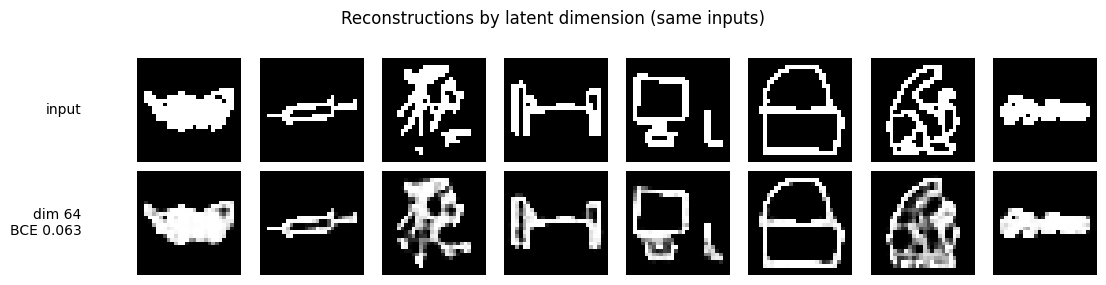

In [11]:
N_SHOW = 8
_va = DataLoader(val_ds, batch_size=N_SHOW, shuffle=True,
                 generator=torch.Generator().manual_seed(SEED))
xb = next(iter(_va))[0].to(DEVICE)               # one shared batch for every model

rows   = sorted(results, key=lambda r: r["latent_dim"])
n_rows = len(rows) + 1                            # +1 for the original-input row
fig, ax = plt.subplots(n_rows, N_SHOW,
                       figsize=(1.4 * N_SHOW, 1.4 * n_rows))

for a in ax.ravel():                              # clean cells but keep ylabels visible
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_visible(False)

for j in range(N_SHOW):                           # top row: originals
    ax[0, j].imshow(xb[j, 0].cpu(), cmap="gray")
ax[0, 0].set_ylabel("input", rotation=0, ha="right", va="center", labelpad=40)

for i, r in enumerate(rows, start=1):             # one row per latent_dim
    model = r["model"].to(DEVICE).eval()
    with torch.no_grad():
        rb = model(xb)
    for j in range(N_SHOW):
        ax[i, j].imshow(rb[j, 0].cpu(), cmap="gray")
    ax[i, 0].set_ylabel(f"dim {r['latent_dim']}\nBCE {r['val_bce']:.3f}",
                        rotation=0, ha="right", va="center", labelpad=40)

plt.suptitle("Reconstructions by latent dimension (same inputs)", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "reconstructions_all_dims.png"), dpi=120)
plt.show()

Best val BCE (any dim):     0.06259
Acceptance threshold (+2%): 0.06384
==> Forced latent_dim (override Z=64): 64  (val BCE=0.06259, MSE=0.01932, params=442,177)


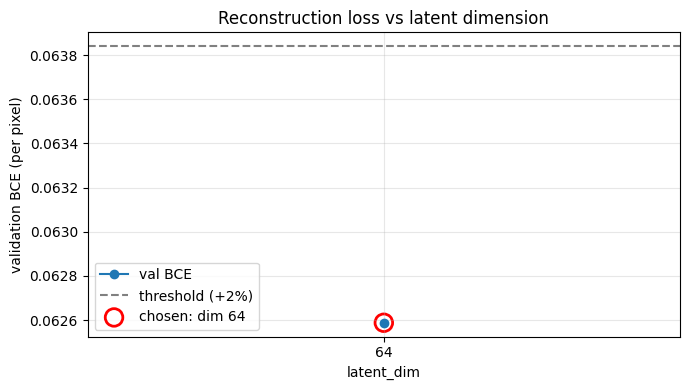

In [12]:
def pick_smallest_dim(results, tol, Z=None):
    """Pick a latent dim from the sweep.

    By default returns the *smallest* dim whose val loss is within `tol` of the
    best. Pass `Z` to override the search and force a specific latent_dim
    (it must be one of the dims that was actually trained in the sweep).
    """
    losses = [r["val_bce"] for r in results]
    best = min(losses)
    threshold = best * (1 + tol)
    if Z is not None:  # manual override: force this latent_dim
        match = next((r for r in results if r["latent_dim"] == Z), None)
        if match is None:
            available = sorted(r["latent_dim"] for r in results)
            raise ValueError(f"No trained model with latent_dim={Z}. Available: {available}")
        return match, threshold
    for r in sorted(results, key=lambda r: r["latent_dim"]):
        if r["val_bce"] <= threshold:
            return r, threshold
    return min(results, key=lambda r: r["latent_dim"]), threshold

# Set FORCE_Z to a specific dim (e.g. 64) to override the automatic pick; leave None to auto-select.
FORCE_Z = 64

chosen, threshold = pick_smallest_dim(results, TOL, Z=FORCE_Z)
best_loss = min(r["val_bce"] for r in results)

print(f"Best val BCE (any dim):     {best_loss:.5f}")
print(f"Acceptance threshold (+{TOL:.0%}): {threshold:.5f}")
if FORCE_Z is not None:
    print(f"==> Forced latent_dim (override Z={FORCE_Z}): {chosen['latent_dim']}  "
          f"(val BCE={chosen['val_bce']:.5f}, MSE={chosen['val_mse']:.5f}, params={chosen['params']:,})")
else:
    print(f"==> Smallest acceptable latent_dim: {chosen['latent_dim']}  "
          f"(val BCE={chosen['val_bce']:.5f}, MSE={chosen['val_mse']:.5f}, params={chosen['params']:,})")

dims   = [r["latent_dim"] for r in results]
losses = [r["val_bce"]    for r in results]
plt.figure(figsize=(7, 4))
plt.plot(dims, losses, "o-", label="val BCE")
plt.axhline(threshold, ls="--", color="gray", label=f"threshold (+{TOL:.0%})")
plt.scatter([chosen["latent_dim"]], [chosen["val_bce"]], s=160, facecolors="none",
            edgecolors="red", linewidths=2, label=f"chosen: dim {chosen['latent_dim']}")
plt.xscale("log", base=2); plt.xticks(dims, dims)
plt.xlabel("latent_dim"); plt.ylabel("validation BCE (per pixel)")
plt.title("Reconstruction loss vs latent dimension"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "latent_sweep.png"), dpi=120); plt.show()

## 7. Inspect reconstructions at the chosen dimension

A quick visual check that the chosen latent size reconstructs your images acceptably for RL.

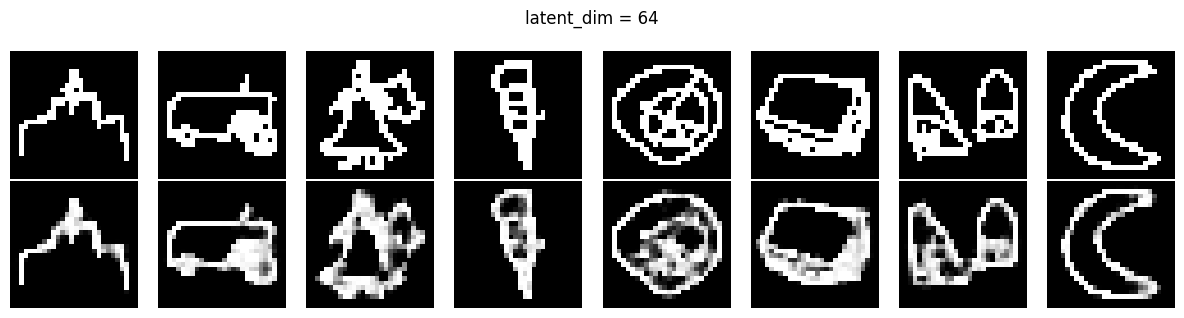

In [13]:
chosen_model = chosen["model"].to(DEVICE).eval()
va = DataLoader(val_ds, batch_size=8, shuffle=True)
xb = next(iter(va))[0].to(DEVICE)
with torch.no_grad():
    rb = chosen_model(xb)
fig, ax = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    ax[0, i].imshow(xb[i, 0].cpu(), cmap="gray"); ax[0, i].axis("off")
    ax[1, i].imshow(rb[i, 0].cpu(), cmap="gray"); ax[1, i].axis("off")
ax[0, 0].set_ylabel("input",  rotation=0, ha="right", labelpad=30)
ax[1, 0].set_ylabel("recon",  rotation=0, ha="right", labelpad=30)
plt.suptitle(f"latent_dim = {chosen['latent_dim']}"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "reconstructions.png"), dpi=120); plt.show()

## 8. Retrain the chosen model on all data and save

The sweep trained on the train split only. Here we retrain the chosen dimension on the full dataset
(train + val) and save the weights plus a small metadata file.

In [14]:
def train_final(latent_dim):
    torch.manual_seed(SEED)
    loader = DataLoader(full, batch_size=BATCH_SIZE, shuffle=True)
    model = ConvAutoencoder(latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    bce_fn = nn.BCELoss()
    epochs = max(chosen["epochs"], 10) # reuse the epoch count found during the sweep
    for ep in range(epochs):
        model.train()
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad(); bce_fn(model(xb), xb).backward(); opt.step()
    return model

final_model = train_final(chosen["latent_dim"])
ckpt_path = os.path.join(OUT_DIR, "autoencoder_best.pt")
torch.save({
    "state_dict": final_model.state_dict(),
    "latent_dim": chosen["latent_dim"],
    "base_ch": BASE_CH,
    "val_bce": chosen["val_bce"],
    "val_mse": chosen["val_mse"],
    "tol": TOL,
}, ckpt_path)
print("Saved:", ckpt_path)

Saved: ae_outputs/autoencoder_best.pt
